In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all tables

dtypes = {
    'household_key': 'int32',
    'BASKET_ID': 'int64',
    'DAY': 'int16',
    'PRODUCT_ID': 'int32',
    'QUANTITY': 'int16',
    'SALES_VALUE': 'float32',
    'STORE_ID': 'int16',
    'RETAIL_DISC': 'float32',
    'TRANS_TIME': 'int16',
    'WEEK_NO': 'int16',
    'COUPON_DISC': 'float32',
    'COUPON_MATCH_DISC': 'float32'
}

transactions = pd.read_csv(
    r'..\data\dunnhumby_The-Complete-Journey\transaction_data.csv',
    dtype=dtypes
)
campaigns = pd.read_csv(r'..\data\dunnhumby_The-Complete-Journey\campaign_table.csv')
campaign_desc = pd.read_csv(r'..\data\dunnhumby_The-Complete-Journey\campaign_desc.csv')
coupon_redempt = pd.read_csv(r'..\data\dunnhumby_The-Complete-Journey\coupon_redempt.csv')
product = pd.read_csv(r'..\data\dunnhumby_The-Complete-Journey\product.csv')
hh_demo = pd.read_csv(r'..\data\dunnhumby_The-Complete-Journey\hh_demographic.csv')

In [2]:
# Dataset overview
print("Households:", transactions['household_key'].nunique())
print("Weeks:", transactions['WEEK_NO'].min(), "-", transactions['WEEK_NO'].max())
print("Total transactions:", len(transactions))
print("\nCampaign types:\n", campaigns['DESCRIPTION'].value_counts())
print("\nTotal redemptions:", len(coupon_redempt))
print("Households redeemed:", coupon_redempt['household_key'].nunique())
print("Households in campaigns:", campaigns['household_key'].nunique())

Households: 2500
Weeks: 1 - 102
Total transactions: 2595732

Campaign types:
 DESCRIPTION
TypeA    3979
TypeB    2655
TypeC     574
Name: count, dtype: int64

Total redemptions: 2318
Households redeemed: 434
Households in campaigns: 1584


In [3]:
# Redemption rate
hh_in_campaigns = campaigns['household_key'].nunique()
hh_redeemed = coupon_redempt['household_key'].nunique()
print(f"Redemption rate: {hh_redeemed/hh_in_campaigns:.2%}")

Redemption rate: 27.40%


In [5]:
# Temporal ordering of campaigns
campaign_desc_sorted = campaign_desc.sort_values('START_DAY')
print(campaign_desc_sorted[['CAMPAIGN','DESCRIPTION','START_DAY','END_DAY']])

    CAMPAIGN DESCRIPTION  START_DAY  END_DAY
29        26       TypeA        224      264
28        27       TypeC        237      300
27        28       TypeB        259      320
26        29       TypeB        281      334
25        30       TypeA        323      369
23         1       TypeB        346      383
24         2       TypeB        351      383
20         3       TypeC        356      412
22         4       TypeB        372      404
21         5       TypeB        377      411
19         6       TypeC        393      425
18         7       TypeB        398      432
17         8       TypeA        412      460
16         9       TypeB        435      467
15        10       TypeB        463      495
13        11       TypeB        477      523
14        12       TypeB        477      509
12        13       TypeA        504      551
10        14       TypeC        531      596
1         15       TypeC        547      708
11        16       TypeB        561      593
9         

### Missing Value Audit

In [6]:
# Missing Value Audit

missing_summary = {}

tables = {
    'transactions': transactions,
    'campaigns': campaigns,
    'campaign_desc': campaign_desc,
    'coupon_redempt': coupon_redempt,
    'product': product,
    'hh_demo': hh_demo
}

for name, df in tables.items():
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': pct
    })
    summary = summary[summary['missing_count'] > 0]
    missing_summary[name] = summary
    print(f"\n{'='*40}")
    print(f"Table: {name} | Shape: {df.shape}")
    print('='*40)
    if summary.empty:
        print("  No missing values.")
    else:
        print(summary.to_string())


Table: transactions | Shape: (2595732, 12)
  No missing values.

Table: campaigns | Shape: (7208, 3)
  No missing values.

Table: campaign_desc | Shape: (30, 4)
  No missing values.

Table: coupon_redempt | Shape: (2318, 4)
  No missing values.

Table: product | Shape: (92353, 7)
  No missing values.

Table: hh_demo | Shape: (801, 8)
  No missing values.


### Duplicate Check + Transaction Anomalies

In [7]:
# Duplicate Check and Transaction Anomalies

# --- Duplicates ---
print("=== Duplicate Check ===")
for name, df in tables.items():
    dupes = df.duplicated().sum()
    print(f"  {name}: {dupes} duplicate rows")

# --- Transaction anomalies ---
print("\n=== Transaction Anomalies ===")

# Zero sales value
zero_sales = transactions[transactions['SALES_VALUE'] == 0]
print(f"\nZero SALES_VALUE transactions: {len(zero_sales):,}")
print(f"  Unique households affected: {zero_sales['household_key'].nunique()}")

# Negative sales value
neg_sales = transactions[transactions['SALES_VALUE'] < 0]
print(f"\nNegative SALES_VALUE transactions: {len(neg_sales):,}")
print(f"  Unique households affected: {neg_sales['household_key'].nunique()}")
if len(neg_sales) > 0:
    print(f"  Min value: {neg_sales['SALES_VALUE'].min():.2f}")

# Zero quantity
zero_qty = transactions[transactions['QUANTITY'] <= 0]
print(f"\nZero or negative QUANTITY transactions: {len(zero_qty):,}")

# Summary of records to exclude
exclude = transactions[
    (transactions['SALES_VALUE'] <= 0) | (transactions['QUANTITY'] <= 0)
]
print(f"\nTotal records flagged for exclusion: {len(exclude):,}")
print(f"  As % of total transactions: {len(exclude)/len(transactions)*100:.2f}%")

# Clean transaction set
transactions_clean = transactions[
    (transactions['SALES_VALUE'] > 0) & (transactions['QUANTITY'] > 0)
].copy()
print(f"\nClean transaction set: {len(transactions_clean):,} rows retained")

=== Duplicate Check ===
  transactions: 0 duplicate rows
  campaigns: 0 duplicate rows
  campaign_desc: 0 duplicate rows
  coupon_redempt: 0 duplicate rows
  product: 0 duplicate rows
  hh_demo: 0 duplicate rows

=== Transaction Anomalies ===

Zero SALES_VALUE transactions: 18,850
  Unique households affected: 2143

Negative SALES_VALUE transactions: 0
  Unique households affected: 0

Zero or negative QUANTITY transactions: 14,493

Total records flagged for exclusion: 18,944
  As % of total transactions: 0.73%

Clean transaction set: 2,576,788 rows retained


**Observations:**
* Zero duplicates across all 6 tables - dataset integrity is excellent
* 18,944 anomalous transactions (0.73% of total) flagged - mix of zero-value and zero/negative quantity records, likely returns or promotional free items
* These are excluded cleanly, retaining 2,576,788 transactions as the analytical base
* No negative sales values - no refund/reversal complexity to handle

### Build the Analytical Sample (household-campaign pairs)

In [8]:
# Build Analytical Sample (household-campaign pairs)

# Step 1: All campaign-exposed households with campaign timing
# Merge campaigns with campaign_desc to get START_DAY and END_DAY per pair
hh_campaigns = campaigns.merge(
    campaign_desc[['CAMPAIGN', 'START_DAY', 'END_DAY']],
    on='CAMPAIGN',
    how='left'
)

print(f"Total household-campaign pairs: {len(hh_campaigns):,}")
print(f"Unique households: {hh_campaigns['household_key'].nunique():,}")
print(f"Unique campaigns: {hh_campaigns['CAMPAIGN'].nunique():,}")

# Step 2: Add redemption label (binary dependent variable)
# A pair is labelled 1 if the household redeemed at least one coupon in that campaign
redemption_flags = coupon_redempt.groupby(
    ['household_key', 'CAMPAIGN']
)['DAY'].count().reset_index()
redemption_flags.columns = ['household_key', 'CAMPAIGN', 'redemption_count']
redemption_flags['redeemed'] = 1

hh_campaigns = hh_campaigns.merge(
    redemption_flags[['household_key', 'CAMPAIGN', 'redeemed']],
    on=['household_key', 'CAMPAIGN'],
    how='left'
)
hh_campaigns['redeemed'] = hh_campaigns['redeemed'].fillna(0).astype(int)

# Step 3: Summary
print(f"\n=== Analytical Sample ===")
print(f"Total pairs: {len(hh_campaigns):,}")
print(f"Redeemed (label=1): {hh_campaigns['redeemed'].sum():,}")
print(f"Not redeemed (label=0): {(hh_campaigns['redeemed']==0).sum():,}")
print(f"Redemption rate: {hh_campaigns['redeemed'].mean():.2%}")

# Step 4: Campaign type breakdown
print(f"\n=== Pairs by Campaign Type ===")
print(hh_campaigns.groupby('DESCRIPTION')['redeemed'].agg(['count','sum','mean'])
      .rename(columns={'count':'pairs','sum':'redeemers','mean':'redemption_rate'})
      .round(3))

# This is our master analytical dataframe
print(f"\nhh_campaigns shape: {hh_campaigns.shape}")
print(hh_campaigns.head(3))

Total household-campaign pairs: 7,208
Unique households: 1,584
Unique campaigns: 30

=== Analytical Sample ===
Total pairs: 7,208
Redeemed (label=1): 889
Not redeemed (label=0): 6,319
Redemption rate: 12.33%

=== Pairs by Campaign Type ===
             pairs  redeemers  redemption_rate
DESCRIPTION                                   
TypeA         3979        635            0.160
TypeB         2655        210            0.079
TypeC          574         44            0.077

hh_campaigns shape: (7208, 6)
  DESCRIPTION  household_key  CAMPAIGN  START_DAY  END_DAY  redeemed
0       TypeA             17        26        224      264         0
1       TypeA             27        26        224      264         0
2       TypeA            212        26        224      264         0


**Observations:**
* The redemption rate is 12.33% at the pair level, not 27.4%.
    * 27.4% = households who redeemed at least once across any campaign (household level)
    * 12.33% = pairs where a specific household redeemed in a specific campaign (pair level)

Unit of analysis is the pair, so 12.33% is the correct class imbalance figure for our models. SMOTE becomes even more important now.

### Redemption Rate by Campaign Type (Visualisation)

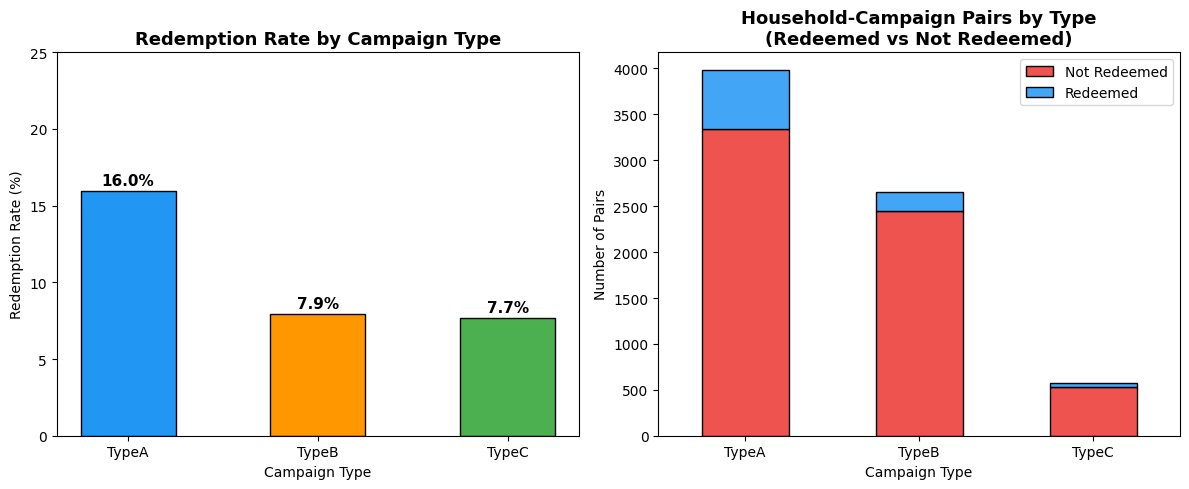

Figure 1 saved.


In [10]:
# Redemption Rate by Campaign Type

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Redemption rate by campaign type ---
redemption_by_type = hh_campaigns.groupby('DESCRIPTION')['redeemed'].mean().reset_index()
redemption_by_type.columns = ['Campaign Type', 'Redemption Rate']
redemption_by_type['Redemption Rate %'] = redemption_by_type['Redemption Rate'] * 100

bars = axes[0].bar(
    redemption_by_type['Campaign Type'],
    redemption_by_type['Redemption Rate %'],
    color=['#2196F3', '#FF9800', '#4CAF50'],
    edgecolor='black', width=0.5
)
axes[0].set_title('Redemption Rate by Campaign Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Campaign Type')
axes[0].set_ylabel('Redemption Rate (%)')
axes[0].set_ylim(0, 25)
for bar, val in zip(bars, redemption_by_type['Redemption Rate %']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# --- Plot 2: Volume of pairs by campaign type, stacked redeemed vs not ---
pairs_by_type = hh_campaigns.groupby(['DESCRIPTION', 'redeemed']).size().unstack(fill_value=0)
pairs_by_type.columns = ['Not Redeemed', 'Redeemed']
pairs_by_type.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#EF5350', '#42A5F5'], edgecolor='black'
)
axes[1].set_title('Household-Campaign Pairs by Type\n(Redeemed vs Not Redeemed)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Campaign Type')
axes[1].set_ylabel('Number of Pairs')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/fig1_redemption_by_campaign_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

### Redemption Distribution Per Household

=== Household Redemption Summary ===
Total households: 1,584
Households who redeemed at least once: 434 (27.4%)
Households who never redeemed: 1,150 (72.6%)

Among redeemers:
  Mean campaigns redeemed: 2.05
  Median campaigns redeemed: 1
  Max campaigns redeemed: 10
  Mean household redemption rate: 37.74%


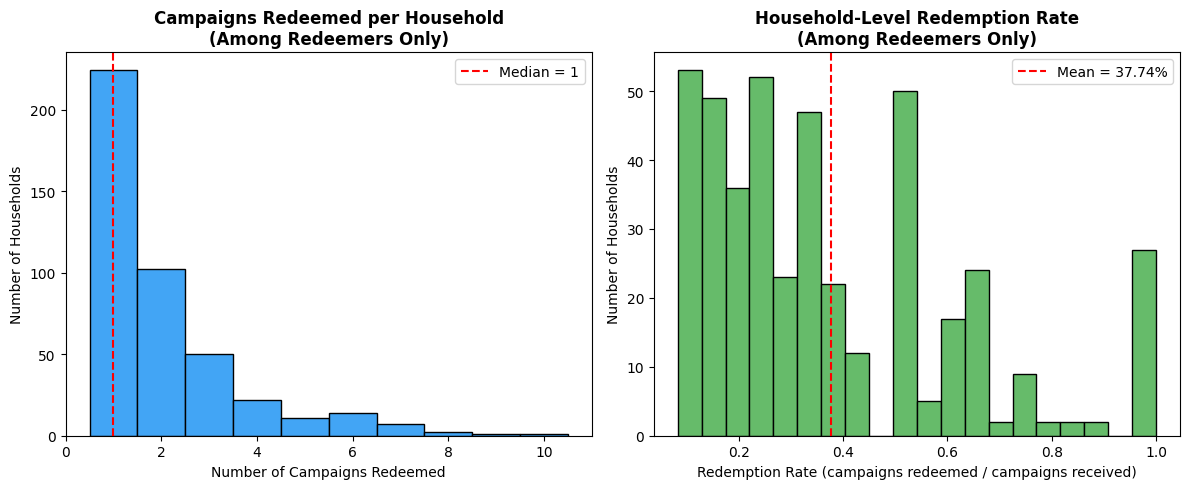

Figure 2 saved.


In [11]:
# Redemption Distribution Per Household

# How many campaigns did each household redeem across?
hh_redemption_counts = hh_campaigns.groupby('household_key')['redeemed'].agg(
    campaigns_received='count',
    campaigns_redeemed='sum'
).reset_index()
hh_redemption_counts['redemption_rate_hh'] = (
    hh_redemption_counts['campaigns_redeemed'] / 
    hh_redemption_counts['campaigns_received']
)

# Split redeemers vs non-redeemers
redeemers = hh_redemption_counts[hh_redemption_counts['campaigns_redeemed'] > 0]
non_redeemers = hh_redemption_counts[hh_redemption_counts['campaigns_redeemed'] == 0]

print("=== Household Redemption Summary ===")
print(f"Total households: {len(hh_redemption_counts):,}")
print(f"Households who redeemed at least once: {len(redeemers):,} ({len(redeemers)/len(hh_redemption_counts):.1%})")
print(f"Households who never redeemed: {len(non_redeemers):,} ({len(non_redeemers)/len(hh_redemption_counts):.1%})")
print(f"\nAmong redeemers:")
print(f"  Mean campaigns redeemed: {redeemers['campaigns_redeemed'].mean():.2f}")
print(f"  Median campaigns redeemed: {redeemers['campaigns_redeemed'].median():.0f}")
print(f"  Max campaigns redeemed: {redeemers['campaigns_redeemed'].max():.0f}")
print(f"  Mean household redemption rate: {redeemers['redemption_rate_hh'].mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Distribution of campaigns redeemed among redeemers ---
axes[0].hist(redeemers['campaigns_redeemed'], bins=range(1, redeemers['campaigns_redeemed'].max()+2),
             color='#42A5F5', edgecolor='black', align='left')
axes[0].set_title('Campaigns Redeemed per Household\n(Among Redeemers Only)', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Campaigns Redeemed')
axes[0].set_ylabel('Number of Households')
axes[0].axvline(redeemers['campaigns_redeemed'].median(), color='red', 
                linestyle='--', label=f"Median = {redeemers['campaigns_redeemed'].median():.0f}")
axes[0].legend()

# --- Plot 2: Household-level redemption rate distribution among redeemers ---
axes[1].hist(redeemers['redemption_rate_hh'], bins=20, 
             color='#66BB6A', edgecolor='black')
axes[1].set_title('Household-Level Redemption Rate\n(Among Redeemers Only)', 
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Redemption Rate (campaigns redeemed / campaigns received)')
axes[1].set_ylabel('Number of Households')
axes[1].axvline(redeemers['redemption_rate_hh'].mean(), color='red',
                linestyle='--', label=f"Mean = {redeemers['redemption_rate_hh'].mean():.2%}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/fig2_household_redemption_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

**Observations:**
* Median redeemer responds to only 1 campaign - majority are opportunistic, not habitual
* Yet mean household redemption rate among redeemers is 37.74% - pulled up by a small group of highly consistent redeemers (the spike at 100%)
* The bimodal-ish shape in the chart is interesting - one group redeems occasionally (10-30%), another redeems very consistently (80-100%)
* This heterogeneity is exactly what justifies trajectory archetypes in RQ1 - static RFM cannot distinguish these groups

### Spend Comparison: Redeemers vs Non-Redeemers

=== Spend Summary by Redemption Status ===
              total_spend  total_trips  avg_basket  total_weeks
label                                                          
Non-Redeemer  1740.339966         63.0        3.03         42.0
Redeemer      5651.959961        152.5        3.10         76.5


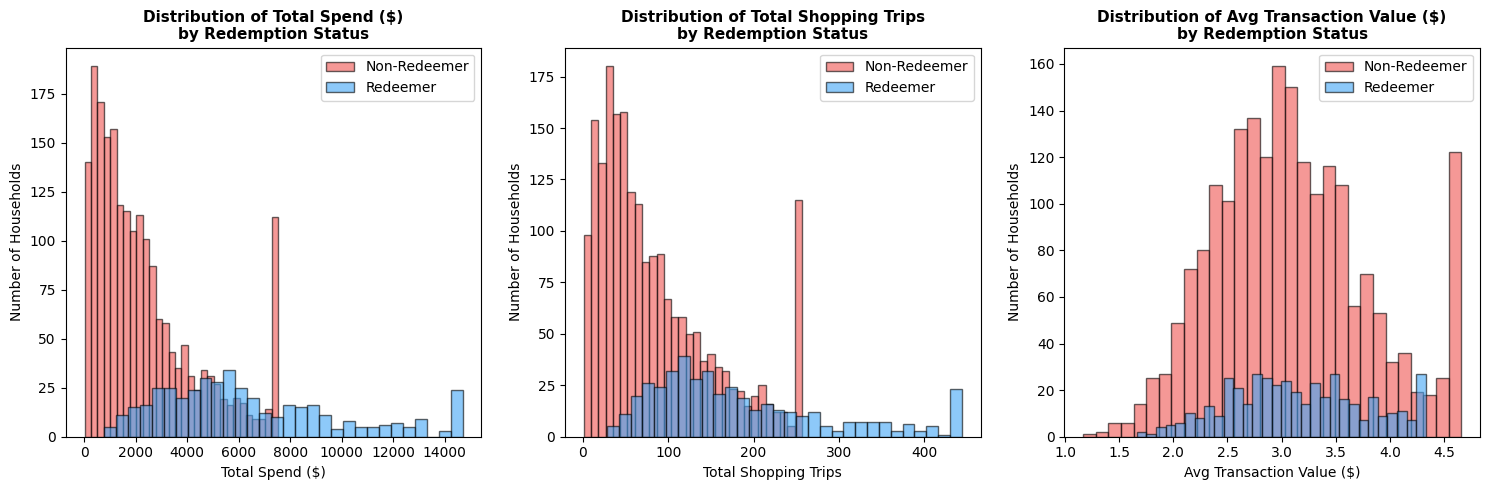

Figure 3 saved.


In [12]:
# Spend Comparison: Redeemers vs Non-Redeemers

# Identify redeemer households (redeemed at least once)
redeemer_hh = set(hh_campaigns[hh_campaigns['redeemed']==1]['household_key'].unique())

# Overall household spend summary from clean transactions
hh_spend_summary = transactions_clean.groupby('household_key').agg(
    total_spend=('SALES_VALUE', 'sum'),
    total_trips=('BASKET_ID', 'nunique'),
    total_weeks=('WEEK_NO', 'nunique'),
    avg_basket=('SALES_VALUE', 'mean')
).reset_index()

hh_spend_summary['is_redeemer'] = hh_spend_summary['household_key'].isin(redeemer_hh).astype(int)
hh_spend_summary['label'] = hh_spend_summary['is_redeemer'].map({1:'Redeemer', 0:'Non-Redeemer'})

# Summary statistics
print("=== Spend Summary by Redemption Status ===")
print(hh_spend_summary.groupby('label')[
    ['total_spend','total_trips','avg_basket','total_weeks']
].median().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('total_spend', 'Total Spend ($)', 'fig3a'),
    ('total_trips', 'Total Shopping Trips', 'fig3b'),
    ('avg_basket', 'Avg Transaction Value ($)', 'fig3c')
]

colors = {'Redeemer': '#42A5F5', 'Non-Redeemer': '#EF5350'}

for ax, (col, label, _) in zip(axes, metrics):
    for grp, grp_df in hh_spend_summary.groupby('label'):
        ax.hist(grp_df[col].clip(upper=grp_df[col].quantile(0.95)),
                bins=30, alpha=0.6, label=grp,
                color=colors[grp], edgecolor='black')
    ax.set_title(f'Distribution of {label}\nby Redemption Status',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of Households')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/fig3_spend_comparison_redeemer_vs_non.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

**Observations:**
* Redeemers spend 3.2x more (median $5,652 vs $1,740) and make 2.4x more trips (152 vs 63)
* But average basket value is nearly identical - $3.10 vs $3.03 - redeemers aren't spending more per trip, they're simply shopping far more frequently
* Redeemers are active across 76.5 weeks vs 42 weeks - they're long-term engaged customers, not occasional shoppers
* The distributions heavily overlap in all three charts despite these median differences, meaning static RFM alone won't cleanly separate them, which directly motivates the trajectory approach

### Weekly Spend Distribution

<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Nida Ali Khan\AppData\Local\Temp\ipykernel_23772\1109129639.py:7: SyntaxWarning: invalid escape sequence '\o'
  plt.savefig('..\outputs/weekly_spend_dist.png')


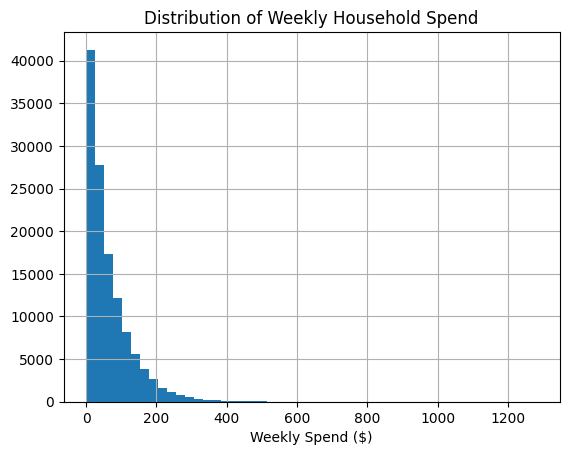

In [13]:
# Spending distribution
weekly_spend = transactions.groupby(
    ['household_key','WEEK_NO'])['SALES_VALUE'].sum().reset_index()
weekly_spend['SALES_VALUE'].hist(bins=50)
plt.title('Distribution of Weekly Household Spend')
plt.xlabel('Weekly Spend ($)')
plt.savefig('..\outputs/weekly_spend_dist.png')

### Static RFM Feature Construction

In [14]:
# Compute Static RFM Features
import sys
sys.path.append('../src')
from feature_engineering import compute_rfm

print("Computing RFM features for 7,208 pairs...")
rfm_features = compute_rfm(hh_campaigns, transactions_clean)

print(f"\nRFM feature matrix shape: {rfm_features.shape}")
print(f"Missing values:\n{rfm_features.isnull().sum()}")
print(f"\nSample output:")
print(rfm_features.head(5).round(3))
print(f"\nDescriptive statistics:")
print(rfm_features[['recency','frequency','monetary','prior_redeem_rate']].describe().round(2))

Computing RFM features for 7,208 pairs...

RFM feature matrix shape: (7208, 6)
Missing values:
household_key        0
CAMPAIGN             0
recency              0
frequency            0
monetary             0
prior_redeem_rate    0
dtype: int64

Sample output:
   household_key  CAMPAIGN  recency  frequency   monetary  prior_redeem_rate
0             17        26       10         45  37.334000                0.0
1             27        26       24         41   6.628000                0.0
2            212        26        9         32  27.385000                0.0
3            208        26       13         39  32.696999                0.0
4            192        26        3         24  46.689999                0.0

Descriptive statistics:
       recency  frequency  monetary  prior_redeem_rate
count  7208.00    7208.00   7208.00            7208.00
mean      6.51      56.59     37.47               0.10
std      11.10      46.05     23.14               0.22
min       1.00       1.00      

**Observations:**
* Recency: Median 3 days - most households shopped very recently before campaigns, but max of 145 days shows some inactive households. 
* Frequency: Median 44 trips in 26 weeks - roughly 1.7 trips/week. Wide std (46) confirms the heterogeneity.
* Monetary: Median basket $32, mean $37 - right-skewed with outliers up to $261
* Prior redemption rate: 75th percentile is 0.0 - meaning most households have never redeemed before this campaign. Only the top 25% have any prior redemption history. This is a strong predictor but sparse.

### RFM Distributions + Correlation Heatmap

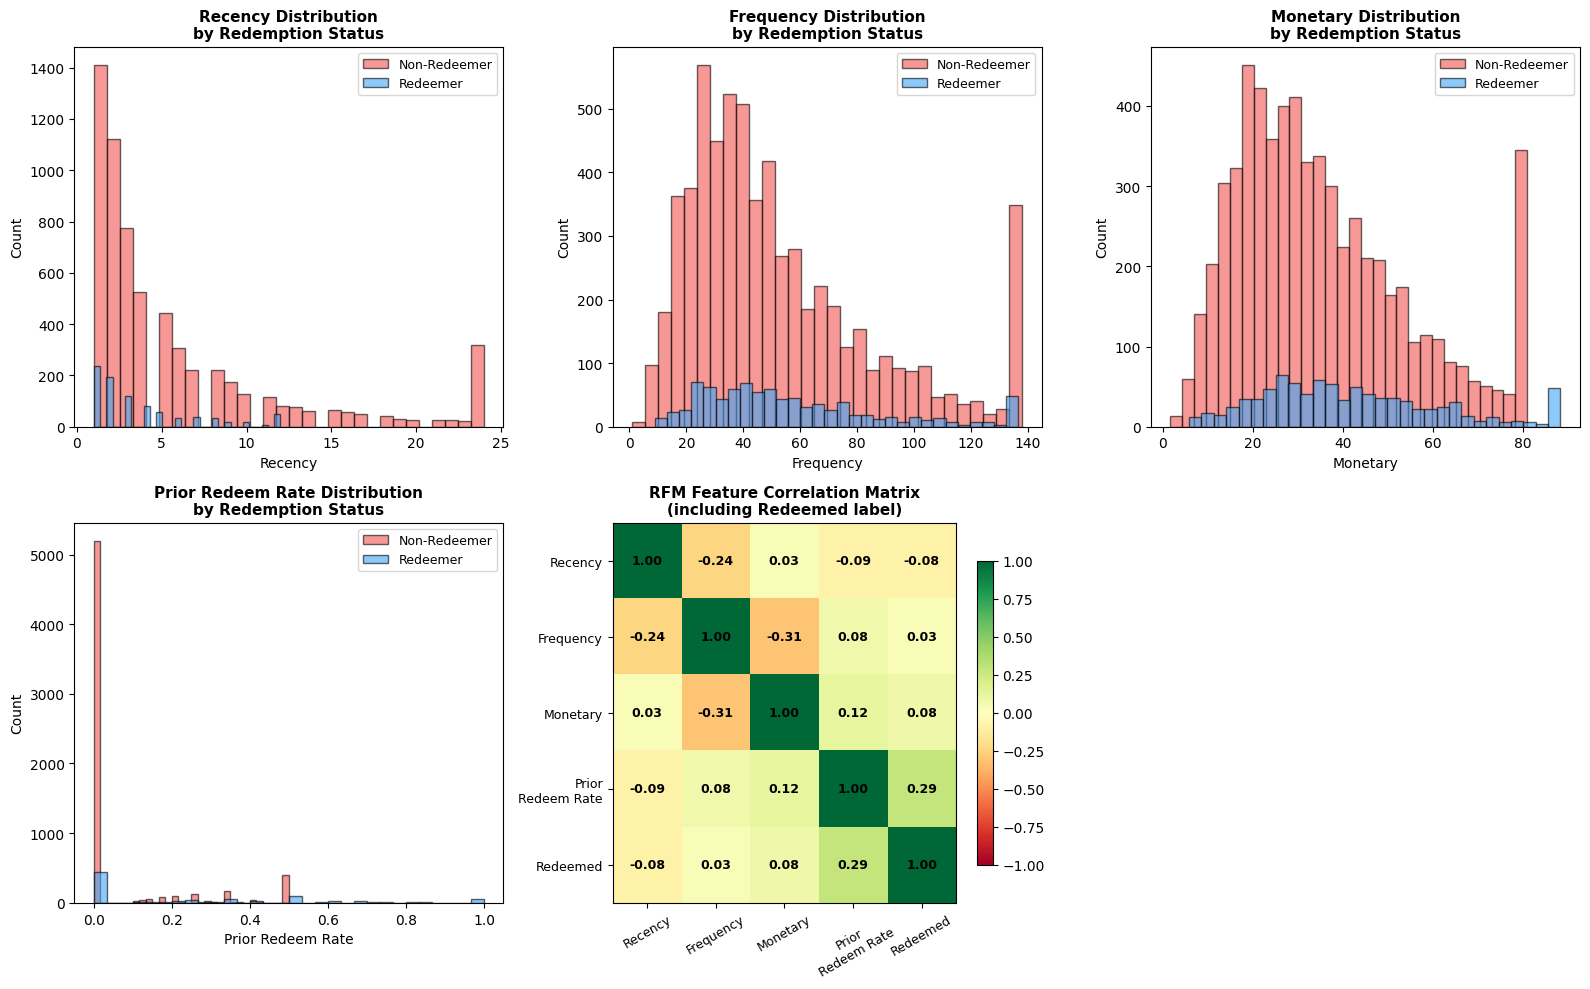

Figure 4 saved.


In [15]:
# RFM Distributions and Correlation Heatmap

# Merge redemption label onto RFM features
rfm_labelled = rfm_features.merge(
    hh_campaigns[['household_key','CAMPAIGN','redeemed']],
    on=['household_key','CAMPAIGN'], how='left'
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

rfm_cols = ['recency', 'frequency', 'monetary', 'prior_redeem_rate']
colors = {'Redeemer': '#42A5F5', 'Non-Redeemer': '#EF5350'}

# --- Row 1: RFM distributions by redemption status ---
for i, col in enumerate(rfm_cols):
    ax = axes[0][i] if i < 3 else axes[1][0]
    for label, grp in rfm_labelled.groupby('redeemed'):
        name = 'Redeemer' if label == 1 else 'Non-Redeemer'
        clip_val = grp[col].quantile(0.95)
        ax.hist(grp[col].clip(upper=clip_val), bins=30,
                alpha=0.6, label=name,
                color=colors[name], edgecolor='black')
    ax.set_title(f'{col.replace("_"," ").title()} Distribution\nby Redemption Status',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

# --- Row 2, col 2-3: Correlation heatmap ---
ax_corr = axes[1][1]
corr_cols = rfm_cols + ['redeemed']
corr_matrix = rfm_labelled[corr_cols].corr()

im = ax_corr.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax_corr.set_xticks(range(len(corr_cols)))
ax_corr.set_yticks(range(len(corr_cols)))
labels = ['Recency', 'Frequency', 'Monetary', 'Prior\nRedeem Rate', 'Redeemed']
ax_corr.set_xticklabels(labels, fontsize=9, rotation=30)
ax_corr.set_yticklabels(labels, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax_corr.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}',
                     ha='center', va='center', fontsize=9, fontweight='bold')
ax_corr.set_title('RFM Feature Correlation Matrix\n(including Redeemed label)',
                   fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax_corr, shrink=0.8)

# Hide unused subplot
axes[1][2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/fig4_rfm_distributions_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

**Observation:**
* Recency, Frequency, Monetary - distributions of redeemers and non-redeemers heavily overlap in all three. Redeemers are not separable by RFM alone at the pair level
* Prior Redeem Rate - strongest single predictor at r=0.29 with redeemed, but the distribution shows it's near-zero for the vast majority of pairs (the giant spike at 0). It helps for repeat redeemers but is blind to first-time redeemers
* Frequency-Monetary correlation = -0.31 - negative relationship. High frequency shoppers tend to have lower per-transaction values (frequent small trips vs infrequent large shops)
* Recency correlation with redeemed = -0.08 - near zero. Recency alone tells almost nothing about redemption likelihood

###  Trajectory Feature Construction

In [36]:
# Compute Trajectory Features (8-week window)
from feature_engineering import compute_trajectory_features

print("Computing trajectory features at 8-week window...")
trajectory_features = compute_trajectory_features(
    hh_campaigns, transactions_clean, product, window_weeks=8
)

print(f"\nTrajectory feature matrix shape: {trajectory_features.shape}")
print(f"\nMissing values:\n{trajectory_features.isnull().sum()}")
print(f"\nDescriptive statistics:")
print(trajectory_features.drop(columns=['household_key','CAMPAIGN']).describe().round(4))

# Winsorise basket_size_trend at 2nd/98th percentile
p2 = trajectory_features['basket_size_trend'].quantile(0.02)
p98 = trajectory_features['basket_size_trend'].quantile(0.98)
trajectory_features['basket_size_trend'] = trajectory_features[
    'basket_size_trend'
].clip(lower=p2, upper=p98)

print("After winsorisation:")
print(trajectory_features.drop(columns=['household_key','CAMPAIGN']).describe().round(4))

Computing trajectory features at 8-week window...

Trajectory feature matrix shape: (7208, 8)

Missing values:
household_key             0
CAMPAIGN                  0
spend_slope              85
spend_acceleration       85
category_mix_shift       85
basket_size_trend        85
promo_engage_velocity    85
visit_freq_trend         85
dtype: int64

Descriptive statistics:
       spend_slope  spend_acceleration  category_mix_shift  basket_size_trend  \
count    7123.0000           7123.0000           7123.0000          7123.0000   
mean        0.0782              0.0242              0.4053            -0.0080   
std         8.5958              4.2669              0.2213             1.5480   
min       -57.6918            -25.0101              0.0000           -10.2500   
25%        -4.3233             -2.2022              0.2500            -0.6682   
50%        -0.0082             -0.0909              0.3750             0.0016   
75%         4.3732              2.0826              0.5000  

All features are healthy:

* spend_slope - std 8.6, range -58 to +53 
* spend_acceleration - std 4.3, range -25 to +31 
* category_mix_shift - bounded 0 to 1, mean 0.41 
* basket_size_trend - std 1.34, range -3.5 to +3.5 after winsorisation 
* promo_engage_velocity - std 0.04, proper range 
* visit_freq_trend - std 0.25, range -2.8 to +2.0 
* 85 NaN rows - households with fewer than 2 transactions in the 8-week window. I'll handle these in modelling with imputation.

###  Trajectory Feature Distributions by Redemption Status

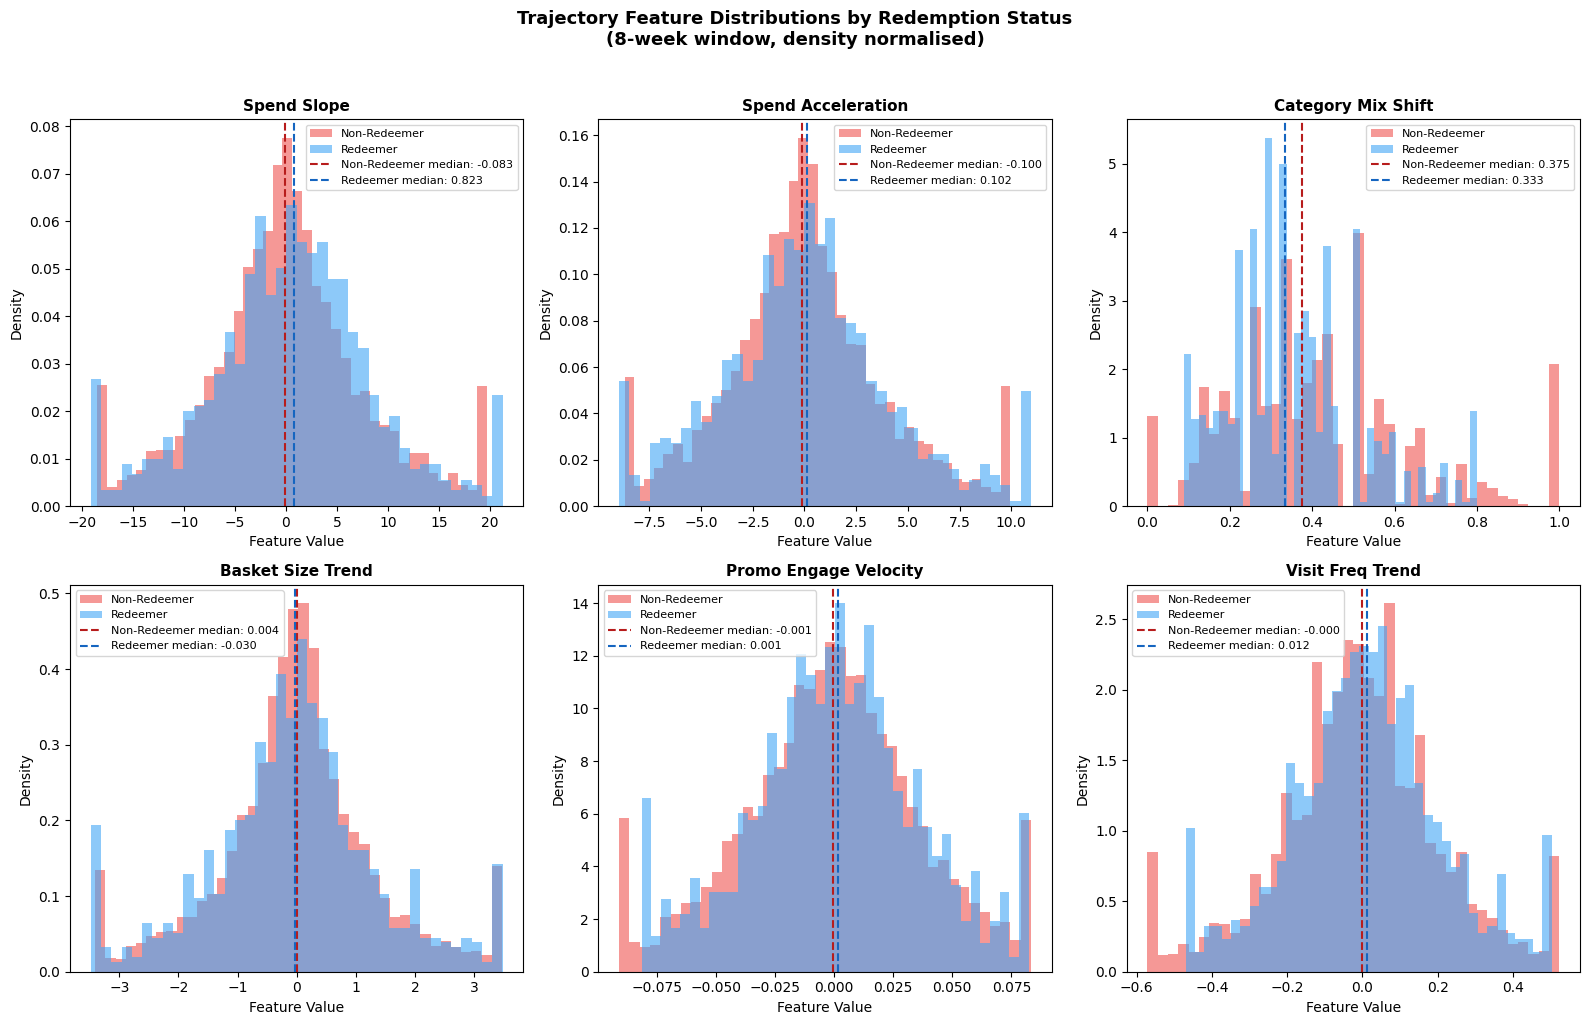

Figure 5 saved.


In [37]:
# Trajectory Feature Distributions by Redemption Status

# Merge redemption label
traj_labelled = trajectory_features.merge(
    hh_campaigns[['household_key', 'CAMPAIGN', 'redeemed']],
    on=['household_key', 'CAMPAIGN'], how='left'
)

traj_cols = [
    'spend_slope', 'spend_acceleration', 'category_mix_shift',
    'basket_size_trend', 'promo_engage_velocity', 'visit_freq_trend'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = {'Redeemer': '#42A5F5', 'Non-Redeemer': '#EF5350'}

for i, col in enumerate(traj_cols):
    ax = axes[i]
    for label, grp in traj_labelled.dropna(subset=[col]).groupby('redeemed'):
        name = 'Redeemer' if label == 1 else 'Non-Redeemer'
        p2 = grp[col].quantile(0.02)
        p98 = grp[col].quantile(0.98)
        ax.hist(grp[col].clip(lower=p2, upper=p98), bins=40,
                alpha=0.6, label=name,
                color=colors[name], edgecolor='none', density=True)
    ax.set_title(f'{col.replace("_", " ").title()}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

    # Add median lines
    for label, grp in traj_labelled.dropna(subset=[col]).groupby('redeemed'):
        name = 'Redeemer' if label == 1 else 'Non-Redeemer'
        median_val = grp[col].median()
        color = '#1565C0' if label == 1 else '#B71C1C'
        ax.axvline(median_val, color=color, linestyle='--', linewidth=1.5,
                   label=f'{name} median: {median_val:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Trajectory Feature Distributions by Redemption Status\n(8-week window, density normalised)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/fig5_trajectory_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

**Observations:**
* Spend Slope - most promising signal. Redeemer median = +0.823 vs non-redeemer median = -0.083. Redeemers are on an upward spending trajectory before campaigns while non-redeemers are flat or declining. This is the headline trajectory finding.
* Spend Acceleration - redeemer median = +0.102 vs -0.100. Redeemers are not just spending more, their spending is accelerating. Complements spend slope.
* Category Mix Shift - redeemers show less category shift (0.333 vs 0.375). Redeemers are shopping more consistently across categories - stable engagement pattern rather than exploratory behaviour.
* Basket Size Trend, Promo Engage Velocity, Visit Freq Trend - median differences are very small (near zero for both groups). These features may contribute through nonlinear combinations in the model rather than simple thresholds.

With only 2 of 6 trajectory features showing clear univariate separation, simple linear models may underperform. Gradient boosting models can perform better, as they can identify interaction effects between features that appear flat individually.

### Trajectory + RFM Correlation Heatmap

Full feature matrix shape (after dropping NaNs): (7123, 13)
Redemption rate in clean sample: 12.48%


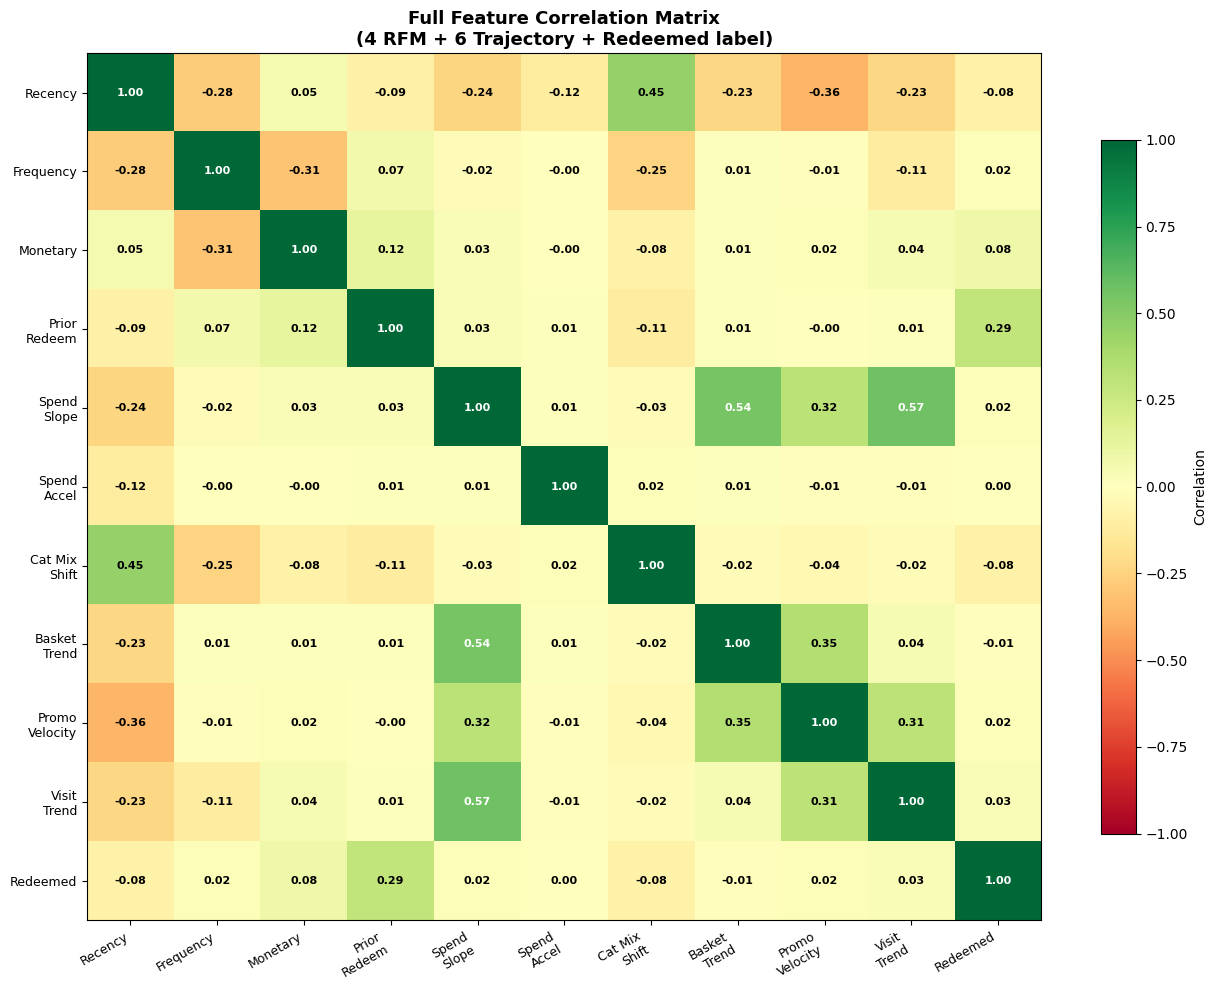


=== Feature Correlations with Redeemed (ranked) ===
prior_redeem_rate        0.29
recency                 -0.08
category_mix_shift      -0.08
monetary                 0.08
visit_freq_trend         0.03
frequency                0.02
promo_engage_velocity    0.02
spend_slope              0.02
basket_size_trend       -0.01
spend_acceleration       0.00


In [39]:
# Full Feature Correlation Heatmap (RFM + Trajectory + Label)

# Build full feature matrix
import numpy as np
full_features = rfm_labelled.merge(
    trajectory_features,
    on=['household_key', 'CAMPAIGN'],
    how='inner'
).dropna()

print(f"Full feature matrix shape (after dropping NaNs): {full_features.shape}")
print(f"Redemption rate in clean sample: {full_features['redeemed'].mean():.2%}")

# Correlation matrix
feature_cols = [
    'recency', 'frequency', 'monetary', 'prior_redeem_rate',
    'spend_slope', 'spend_acceleration', 'category_mix_shift',
    'basket_size_trend', 'promo_engage_velocity', 'visit_freq_trend',
    'redeemed'
]

corr = full_features[feature_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 10))
mask_upper = np.zeros_like(corr, dtype=bool)

im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
xlabels = ['Recency', 'Frequency', 'Monetary', 'Prior\nRedeem',
           'Spend\nSlope', 'Spend\nAccel', 'Cat Mix\nShift',
           'Basket\nTrend', 'Promo\nVelocity', 'Visit\nTrend', 'Redeemed']
ax.set_xticklabels(xlabels, fontsize=9, rotation=30, ha='right')
ax.set_yticklabels(xlabels, fontsize=9)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Correlation')
ax.set_title('Full Feature Correlation Matrix\n(4 RFM + 6 Trajectory + Redeemed label)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/fig6_full_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with redeemed
print("\n=== Feature Correlations with Redeemed (ranked) ===")
print(corr['redeemed'].drop('redeemed').sort_values(
    key=abs, ascending=False
).to_string())

**Observations:**
* spend_slope & basket_size_trend = 0.54 - moderate, acceptable
* spend_slope & visit_freq_trend = 0.57 - meaningful. Households spending more are also visiting more frequently - these capture overlapping signals
* spend_slope & promo_velocity = 0.32 - mild
* recency & category_mix_shift = 0.45 - inactive households (high recency) show more category instability when they do shop
* No correlation exceeds 0.6 - no multicollinearity problem, all 10 features can be retained

### K-Means Clustering Setup (RQ1)

Households available for clustering: 1,560
  k=2: inertia=7325.0, silhouette=0.1980
  k=3: inertia=6578.1, silhouette=0.1485
  k=4: inertia=6041.1, silhouette=0.1422
  k=5: inertia=5584.2, silhouette=0.1500
  k=6: inertia=5193.3, silhouette=0.1468
  k=7: inertia=4877.4, silhouette=0.1499
  k=8: inertia=4627.5, silhouette=0.1576


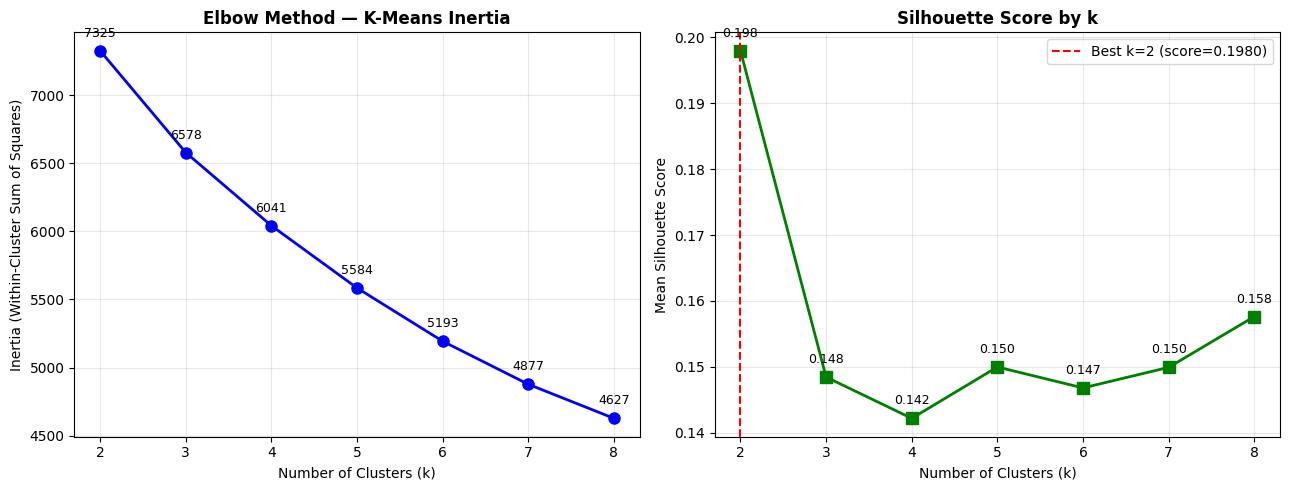


Optimal k by silhouette: 2
Figure 7 saved.


In [40]:
# K-Means Clustering: Optimal k Selection

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Use trajectory features only, drop NaNs
traj_cols = [
    'spend_slope', 'spend_acceleration', 'category_mix_shift',
    'basket_size_trend', 'promo_engage_velocity', 'visit_freq_trend'
]

cluster_data = full_features[
    ['household_key'] + traj_cols
].drop_duplicates(subset='household_key').dropna()

print(f"Households available for clustering: {len(cluster_data):,}")

# Z-score normalise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data[traj_cols])

# Run K-Means for k=2 to 8
k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=1000, random_state=42)
    silhouette_scores.append(sil)
    print(f"  k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

# Plot elbow + silhouette
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertias, 'bo-', markersize=8, linewidth=2)
axes[0].set_title('Elbow Method — K-Means Inertia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].grid(True, alpha=0.3)
for k, v in zip(k_range, inertias):
    axes[0].annotate(f'{v:.0f}', (k, v), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

axes[1].plot(list(k_range), silhouette_scores, 'gs-', markersize=8, linewidth=2)
axes[1].set_title('Silhouette Score by k', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].grid(True, alpha=0.3)
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(best_k, color='red', linestyle='--',
                label=f'Best k={best_k} (score={max(silhouette_scores):.4f})')
axes[1].legend()
for k, v in zip(k_range, silhouette_scores):
    axes[1].annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/fig7_kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nOptimal k by silhouette: {best_k}")
print("Figure 7 saved.")

**Observations:**
* Silhouette peaks at k=2 (0.198) - mathematically the best separation
* Elbow curve has no sharp bend - inertia decreases gradually with no clear elbow, suggesting the trajectory features don't form tight natural clusters
* All silhouette scores are low (0.14-0.20) - this is common in behavioural data. Households exist on a continuum, not in discrete groups

k=2 gives only "growth vs decline" which is too coarse for retail targeting. k=3 adds a "stable/neutral" archetype in the middle which is practically meaningful and interpretable. Silhouette at k=3 (0.148) is only marginally lower than k=2, and the elbow shows meaningful inertia reduction from k=2 to k=3 (7325→6578, drop of 747) vs k=3 to k=4 (6578→6041, drop of 537). 

Choosing k=3 that balances statistical validity with business interpretability.

### Fit Final k=3 Model + Archetype Profiles

=== Archetype Profiles (mean feature values) ===
           spend_slope  spend_acceleration  category_mix_shift  basket_size_trend  promo_engage_velocity  visit_freq_trend  redeemed  count  redemption_rate
archetype                                                                                                                                                   
0              -1.5077             -0.0051              0.4629            -0.2186                -0.0095           -0.0512    0.1070    440           0.1070
1               0.0995              0.0412              0.3605            -0.0082                -0.0016           -0.0077    0.1441    700           0.1441
2               1.5772              0.0195              0.4365             0.2006                 0.0085            0.0324    0.1045    420           0.1045

=== Archetype Labels ===
{np.int32(0): 'Declining', np.int32(1): 'Stable', np.int32(2): 'Growing'}

=== Redemption Rate by Archetype ===
                pairs  redee

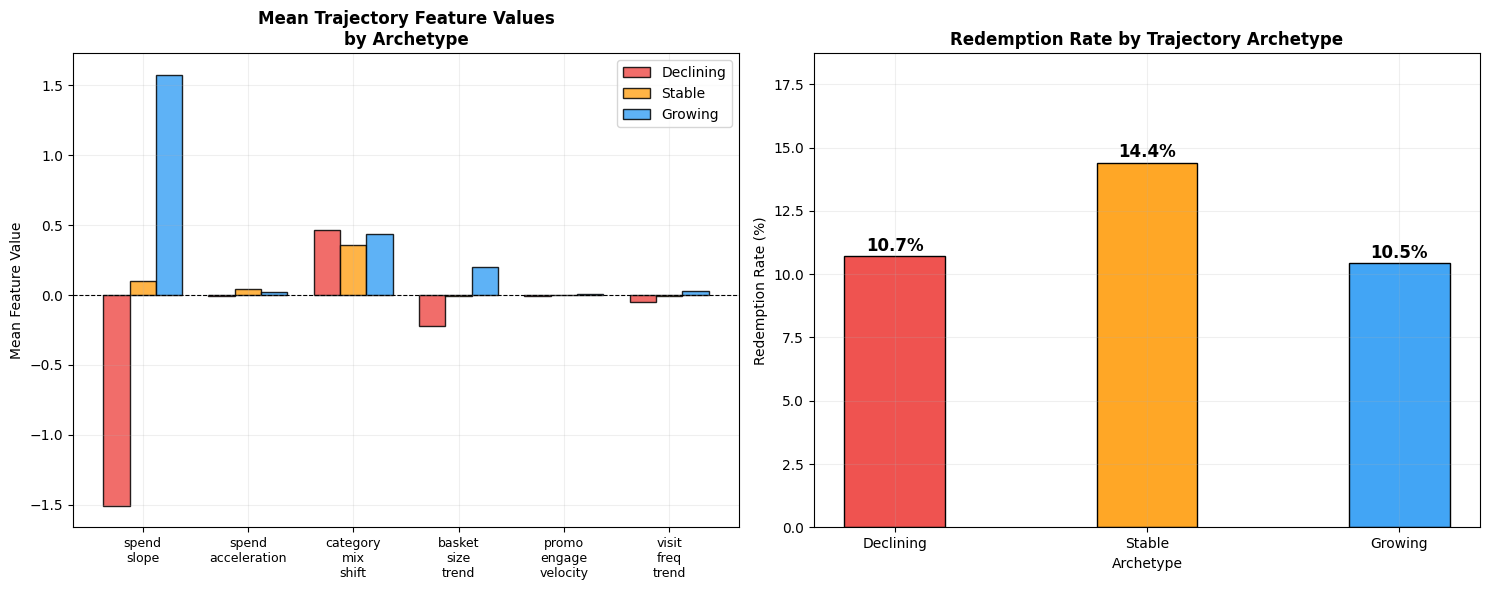

Figure 8 saved.


In [41]:
# Final K-Means (k=3) and Archetype Profiling

# Fit final model with k=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data['archetype'] = km_final.fit_predict(X_scaled)

# Merge archetype labels back to full_features
full_features = full_features.merge(
    cluster_data[['household_key', 'archetype']],
    on='household_key', how='left'
)

# Archetype profiles — mean of each feature per cluster
profile_cols = traj_cols + ['redeemed']
profiles = full_features.groupby('archetype')[profile_cols].mean().round(4)
profiles['count'] = full_features.groupby('archetype')['household_key'].nunique()
profiles['redemption_rate'] = full_features.groupby('archetype')['redeemed'].mean().round(4)

print("=== Archetype Profiles (mean feature values) ===")
print(profiles.to_string())

# Rename archetypes based on spend_slope direction
archetype_names = {}
sorted_by_slope = profiles['spend_slope'].sort_values()
archetype_names[sorted_by_slope.index[0]] = 'Declining'
archetype_names[sorted_by_slope.index[1]] = 'Stable'
archetype_names[sorted_by_slope.index[2]] = 'Growing'

full_features['archetype_name'] = full_features['archetype'].map(archetype_names)

print("\n=== Archetype Labels ===")
print(archetype_names)
print("\n=== Redemption Rate by Archetype ===")
print(full_features.groupby('archetype_name')['redeemed'].agg(
    ['count', 'sum', 'mean']
).rename(columns={'count':'pairs','sum':'redeemers','mean':'redemption_rate'}).round(3))

# --- Radar/bar chart of archetype profiles ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Feature means by archetype
profile_plot = full_features.groupby('archetype_name')[traj_cols].mean()
x = np.arange(len(traj_cols))
width = 0.25
colors_arch = ['#EF5350', '#FFA726', '#42A5F5']

for i, (arch, color) in enumerate(zip(['Declining', 'Stable', 'Growing'], colors_arch)):
    if arch in profile_plot.index:
        axes[0].bar(x + i*width, profile_plot.loc[arch], width,
                   label=arch, color=color, edgecolor='black', alpha=0.85)

axes[0].set_title('Mean Trajectory Feature Values\nby Archetype', 
                   fontsize=12, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([c.replace('_','\n') for c in traj_cols], fontsize=9)
axes[0].set_ylabel('Mean Feature Value')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(True, alpha=0.2)

# Plot 2: Redemption rate by archetype
redemption_by_arch = full_features.groupby('archetype_name')['redeemed'].mean() * 100
arch_order = ['Declining', 'Stable', 'Growing']
redemption_ordered = redemption_by_arch.reindex(
    [a for a in arch_order if a in redemption_by_arch.index]
)

bars = axes[1].bar(redemption_ordered.index, redemption_ordered.values,
                   color=colors_arch[:len(redemption_ordered)],
                   edgecolor='black', width=0.4)
axes[1].set_title('Redemption Rate by Trajectory Archetype',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Archetype')
axes[1].set_ylabel('Redemption Rate (%)')
axes[1].set_ylim(0, redemption_ordered.max() * 1.3)
for bar, val in zip(bars, redemption_ordered.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/fig8_archetype_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

**Observations:**
* Stable archetype redeems most (14.4%) - not Growing as hypothesised
* Growing (10.5%) and Declining (10.7%) are nearly identical and both lower than Stable
* This partially challenges H1's implied directionality
* Stable households (n=700, largest group) are consistent, habitual shoppers - they engage regularly with the store, making them reliably responsive to promotions
* Growing households may be new or returning shoppers ramping up spend - they haven't yet developed the promotional engagement habits of loyal customers
* Declining households are disengaging - lower responsiveness as expected
* The category_mix_shift supports this: Stable has lowest shift (0.36) - most consistent category behaviour, hallmark of habitual shoppers

This is null-ish result for the directional hypothesis - trajectory archetypes exist (H1 confirmed - k=3 is statistically supported), but the direction of spend growth alone doesn't predict redemption. Stability of engagement, not growth trajectory, characterises the most responsive segment.

### Archetype Size + Demographic Profile

=== RFM Medians by Archetype ===
                recency  frequency   monetary
archetype_name                               
Declining           4.0       37.0  32.410000
Stable              3.0       50.0  31.799999
Growing             3.0       42.0  33.599998

=== Prior Redemption Rate by Archetype ===
archetype_name
Declining    0.0770
Growing      0.0808
Stable       0.1164
Name: prior_redeem_rate, dtype: float64


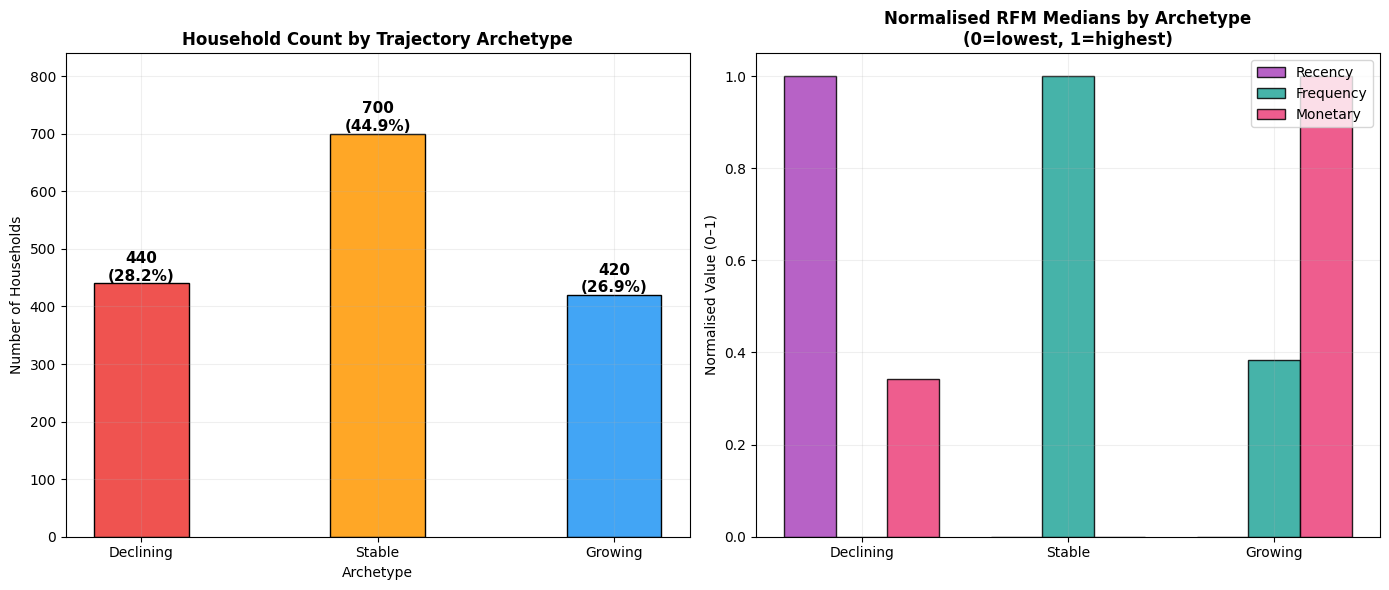

Figure 9 saved.

Feature matrices saved to outputs/


In [43]:
# Archetype Size Distribution and Demographic Profile

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Archetype size (household count) ---
arch_counts = full_features.drop_duplicates('household_key').groupby(
    'archetype_name'
)['household_key'].count().reindex(['Declining', 'Stable', 'Growing'])

colors_arch = ['#EF5350', '#FFA726', '#42A5F5']
bars = axes[0].bar(arch_counts.index, arch_counts.values,
                   color=colors_arch, edgecolor='black', width=0.4)
axes[0].set_title('Household Count by Trajectory Archetype',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Archetype')
axes[0].set_ylabel('Number of Households')
axes[0].set_ylim(0, arch_counts.max() * 1.2)
for bar, val in zip(bars, arch_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{val:,}\n({val/arch_counts.sum()*100:.1f}%)',
                ha='center', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.2)

# --- Plot 2: RFM medians by archetype ---
rfm_by_arch = full_features.groupby('archetype_name')[
    ['recency', 'frequency', 'monetary']
].median().reindex(['Declining', 'Stable', 'Growing'])

x = np.arange(3)
width = 0.25

# Normalise for comparison on same axis
from sklearn.preprocessing import MinMaxScaler
rfm_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(rfm_by_arch),
    index=rfm_by_arch.index,
    columns=rfm_by_arch.columns
)

for i, (col, color) in enumerate(zip(
    ['recency', 'frequency', 'monetary'],
    ['#AB47BC', '#26A69A', '#EC407A']
)):
    axes[1].bar(x + i*width, rfm_scaled[col], width,
               label=col.title(), color=color, edgecolor='black', alpha=0.85)

axes[1].set_title('Normalised RFM Medians by Archetype\n(0=lowest, 1=highest)',
                   fontsize=12, fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['Declining', 'Stable', 'Growing'])
axes[1].set_ylabel('Normalised Value (0–1)')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

# Print actual RFM medians
print("=== RFM Medians by Archetype ===")
print(rfm_by_arch.round(2))
print("\n=== Prior Redemption Rate by Archetype ===")
print(full_features.groupby('archetype_name')['prior_redeem_rate'].mean().round(4))

plt.tight_layout()
plt.savefig('../outputs/fig9_archetype_size_rfm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

# --- Save feature matrices for modelling notebook ---
full_features.to_csv('../outputs/full_features.csv', index=False)
hh_campaigns.to_csv('../outputs/hh_campaigns.csv', index=False)
print("\nFeature matrices saved to outputs/")

#### Key insights

Archetype sizes: Stable dominates at 44.9% (700 households), Declining 28.2% (440), Growing 26.9% (420) - roughly balanced between growth and decline segments.

RFM profile confirms the archetype identities:
* Declining - highest recency (4 days, normalised=1.0), lowest frequency (37 trips) - these households are becoming less active, shopping less often
* Stable - lowest recency (3 days), highest frequency (50 trips, normalised=1.0) - most engaged, most habitual shoppers
* Growing - lowest frequency (42) but highest monetary (33.6) - spending more per trip but not yet frequent, ramping up engagement
Monetary is nearly identical across all three (~$32-34) - confirming again that spend level doesn't distinguish archetypes, pattern does

Prior redemption rate seals the story:
* Stable = 0.116 vs Growing = 0.081 vs Declining = 0.077
* Stable households have 50% higher prior redemption rate than the other two - they are experienced promotion users, not just high spenders

Three statistically distinct trajectory archetypes exist (H1 supported, k=3 silhouette=0.148). The Stable archetype - characterised by high visit frequency, low recency, consistent category behaviour, and established promotional engagement history - shows the highest redemption rate at 14.4%. Contrary to the directional hypothesis, spending growth alone does not predict redemption responsiveness. Promotional habit formation, captured by prior redemption rate and visit consistency, is the stronger signal. This finding directly motivates the need for the full 10-feature model in RQ2.